# RetailPulse AI – Day 2: Data Cleaning & Feature Engineering

### Prepared By: Bansi Kanani

### Date: 30 May 2026

# Introduction

Data cleaning and feature engineering are essential steps in building reliable analytics and machine learning systems.

This notebook focuses on improving data quality, removing invalid transactions, and creating new features that will support customer segmentation, forecasting, churn prediction, and inventory optimization.

# Objective

The objectives of Day 2 are:

- Handle missing values
- Remove cancelled transactions
- Remove invalid records
- Create business-focused features
- Prepare a clean dataset for advanced analytics

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("archive (3)/online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Initial Dataset Shape

Understanding the dataset size before cleaning helps measure the impact of preprocessing operations.

In [3]:
print("Original Shape:", df.shape)

Original Shape: (1067371, 8)


# Missing Value Analysis

Customer identifiers are important for customer analytics and RFM analysis.

Rows with missing customer identifiers will be removed.

In [4]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [5]:
df = df.dropna(
    subset=["Customer ID"]
)

print(
    "After Removing Missing Customer IDs:",
    df.shape
)

After Removing Missing Customer IDs: (824364, 8)


# Duplicate Record Analysis

Duplicate transactions can distort business insights and model performance.

In [6]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 26479


In [7]:
df = df.drop_duplicates()

print(
    "After Removing Duplicates:",
    df.shape
)

After Removing Duplicates: (797885, 8)


# Cancelled Transaction Analysis

Invoices beginning with the letter C indicate cancelled orders.

Cancelled transactions should be removed before analysis.

In [8]:
df[
    df["Invoice"]
    .astype(str)
    .str.startswith("C")
].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [9]:
df = df[
    ~df["Invoice"]
    .astype(str)
    .str.startswith("C")
]

print(
    "After Removing Cancelled Orders:",
    df.shape
)

After Removing Cancelled Orders: (779495, 8)


# Invalid Quantity and Price Analysis

Transactions with negative or zero quantities and prices are not useful for forecasting and customer analysis.

In [10]:
df = df[
    (df["Quantity"] > 0)
    &
    (df["Price"] > 0)
]

print(
    "After Removing Invalid Transactions:",
    df.shape
)

After Removing Invalid Transactions: (779425, 8)


# Revenue Feature Creation

Revenue is a key business metric and will be used throughout the project.

In [11]:
df["Revenue"] = (
    df["Quantity"] *
    df["Price"]
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


# Date Feature Engineering

Date-related features help analyze customer purchasing patterns over time and are useful for forecasting models.

In [12]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [13]:
df["Year"] = (
    df["InvoiceDate"]
    .dt.year
)

df["Month"] = (
    df["InvoiceDate"]
    .dt.month
)

df["Day"] = (
    df["InvoiceDate"]
    .dt.day
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


# Revenue Trend by Month

Understanding monthly revenue trends helps identify seasonality and purchasing behavior.

In [14]:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue

Month
1     1123903.982
2      950643.876
3     1291060.231
4     1060356.333
5     1275188.530
6     1296417.180
7     1188699.071
8     1246275.640
9     1779704.153
10    2068754.460
11    2322665.632
12    1771135.180
Name: Revenue, dtype: float64

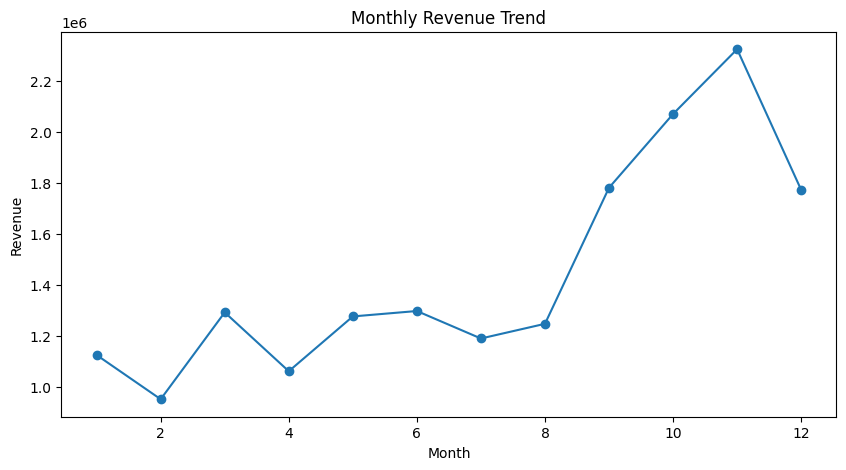

In [15]:
plt.figure(figsize=(10,5))

monthly_revenue.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Monthly Revenue Trend"
)

plt.ylabel(
    "Revenue"
)

plt.show()

# Feature Summary

The following engineered features have been created:

- Revenue
- Year
- Month
- Day

These features will support customer segmentation, forecasting, and machine learning tasks in later stages of the project.

# Business Insights

1. Invalid transactions were successfully removed.

2. Cancelled orders were excluded from the analysis.

3. Customer records were cleaned to improve analytical accuracy.

4. Revenue features were generated for business analysis.

5. Date features were created for forecasting and trend analysis.

The cleaned dataset is now ready for customer segmentation and RFM analysis.

# Challenges Faced

The Online Retail II dataset contains missing customer identifiers, cancelled transactions, and duplicate records.

Careful preprocessing was required to ensure that only valid business transactions were retained for analysis.

In [16]:
df.to_csv(
    "cleaned_online_retail.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


# Saving Cleaned Dataset

The cleaned dataset is saved for use in future stages of the project, including RFM analysis, customer segmentation, forecasting, and machine learning tasks.

# Conclusion

Data cleaning and feature engineering were successfully completed on the Online Retail II dataset.

The dataset is now free from major quality issues and includes business-focused features that will support customer segmentation, forecasting, churn prediction, and inventory optimization in future project stages.